# Building a Deep Learning Regression Model on Power Plant Dataset using ANN

In this project, we work with the **PowerPlant Dataset**, which contains information about environmental conditions affecting power generation. The dataset includes features such as Ambient Temperature (AT), Exhaust Vacuum (V), Ambient Pressure (AP), and Relative Humidity (RH), which influence the overall efficiency of the power plant.

The primary objective of this project is to develop an Artificial Neural Network (ANN) model that can predict the **electrical energy output (PE)** of the power plant based on these environmental factors.

We begin by performing Exploratory Data Analysis (EDA) and data preprocessing to understand the dataset and prepare it for modeling. This includes handling data scaling and ensuring proper input representation. 
Following this, we design and train an ANN model to learn the relationship between input features and power output.

Finally, the model is evaluated using appropriate regression metrics to assess its performance and generalization capability.

In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("powerplant_data.csv")

In [4]:
df.shape

(9568, 5)

In [5]:
df

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43
...,...,...,...,...,...
9563,15.12,48.92,1011.80,72.93,462.59
9564,33.41,77.95,1010.30,59.72,432.90
9565,15.99,43.34,1014.20,78.66,465.96
9566,17.65,59.87,1018.58,94.65,450.93


# Exploratory Data Analysis

In [9]:
print(df.duplicated().sum())
df.info()

41
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [10]:
df[df.duplicated(keep=False)]

,AT,V,AP,RH,PE
37,25.91,75.60,1018.23,62.65,443.20
251,29.45,75.60,1018.12,50.68,437.31
527,29.51,75.60,1017.92,50.61,431.18
545,25.21,75.60,1017.19,69.84,445.84
577,6.86,41.17,1020.12,79.14,490.23
...,...,...,...,...,...
8579,11.61,41.17,1019.57,58.82,476.81
8885,6.40,41.17,1019.54,85.37,488.82
9002,8.44,41.17,1019.90,70.72,486.15
9350,7.87,41.17,1020.33,77.77,486.20


In [11]:
df = df.drop_duplicates()
print(df.duplicated().sum())

0


#### Data is clean with no null and duplicated values

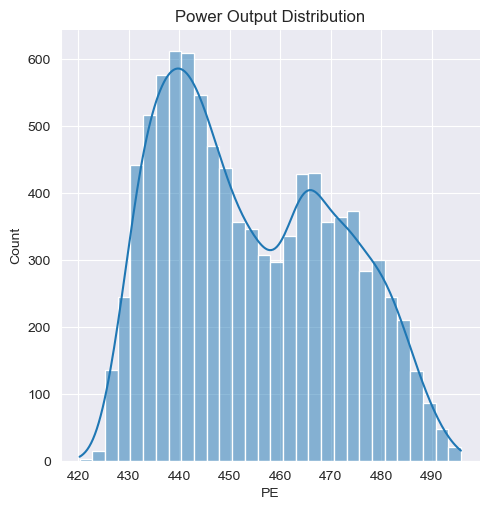

In [93]:
# Output Distribution

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")
sns.color_palette("Set2")
sns.displot(df["PE"], bins=30, kde=True)
plt.title("Power Output Distribution")
plt.show()

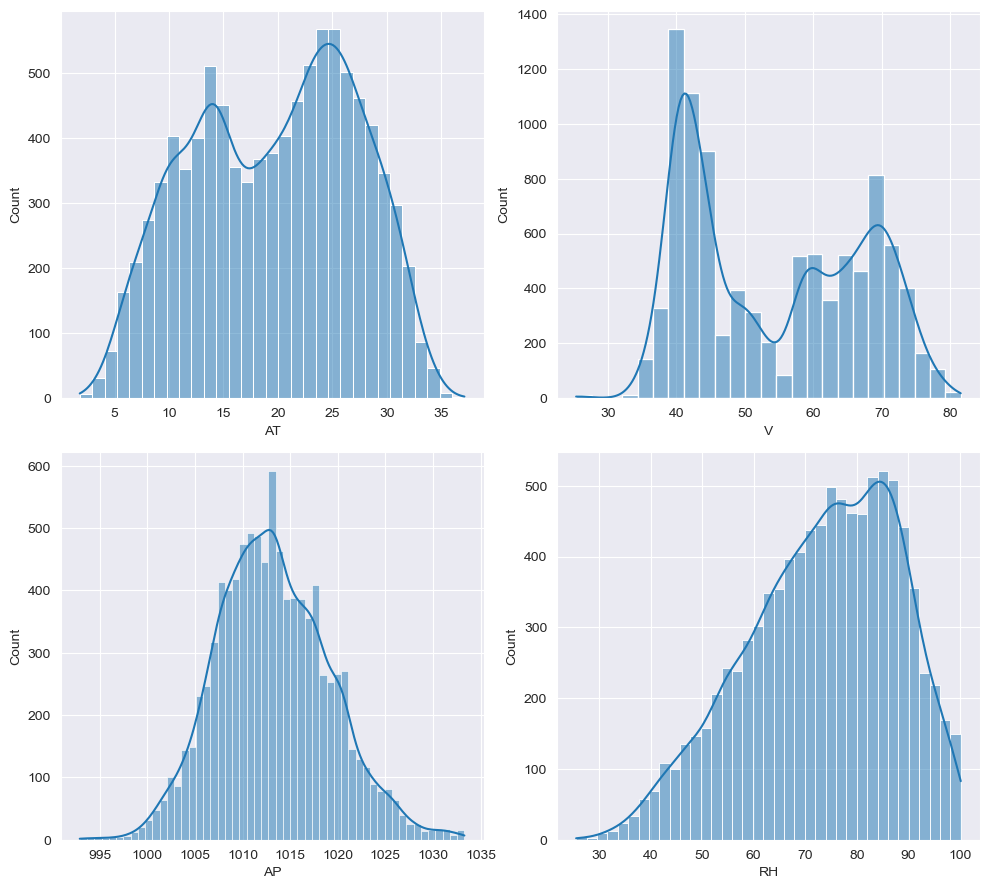

In [99]:
# Feature Distributions
cat_col = df.drop(['PE'], axis=1)

f, axs = plt.subplots(2, 2, figsize=(10, 9))
axs = axs.flatten()

sns.set_style("darkgrid")
sns.color_palette("Set2")

for i, col in enumerate(cat_col):
    sns.histplot(data=df, x=col, ax=axs[i], kde=True)

plt.tight_layout()
plt.show()

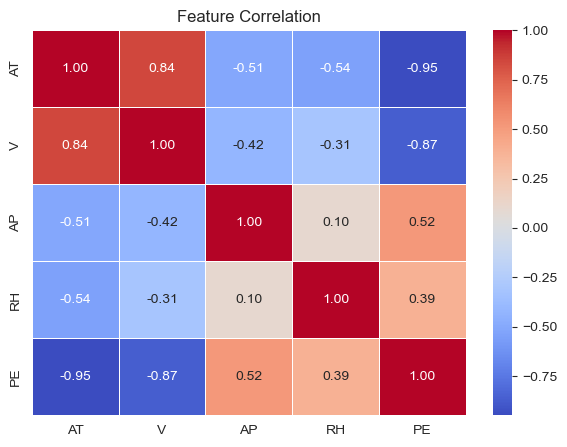

In [100]:
# Feature Correlation

plt.figure(figsize=(7,5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", linewidths=0.5, fmt=".2f")
plt.title("Feature Correlation")
plt.show()

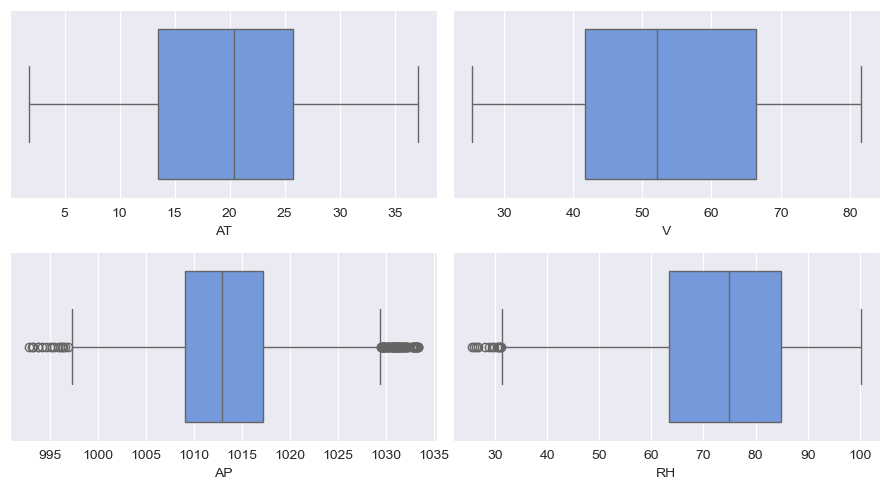

In [102]:
# Outlier Detection

sns.set_style("darkgrid")
f, axs = plt.subplots(2, 2, figsize=(9, 5))
axs = axs.flatten()

sns.set_style("darkgrid")

for i, col in enumerate(cat_col):
    sns.boxplot(data=df, x=col, ax=axs[i], color = "cornflowerblue" )

plt.tight_layout()
plt.show()


## EDA Conclusion-
- Most features are approximately normally distributed with no heavy skewness.
- Temperature (AT) and Vacuum (V) show strong negative correlation with power output (PE).
- Pressure (AP) and Humidity (RH) have moderate positive correlation with PE.
- Minor outliers are present but not significant enough to remove.
- Dataset is clean (duplicates handled, no missing values) and suitable for regression models.

## Data Preprocessing
---

### Data Split

In [103]:
X = df.drop("PE", axis=1)
y = df["PE"]

In [104]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size= 0.2, random_state = 42)

### Scaling Features

In [105]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Data Loaders and Tensor Dataset

In [108]:
import torch 
import torch.nn as nn

# Creating tensors for our training and testing dataset

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [109]:
from torch.utils.data import DataLoader, TensorDataset

# Creating tensor datasets for training & testing to pass data to data loader which can feed data in batches to our model

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Data loader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

# ANN Regressor

### Step_1 - Define ANN model

In [110]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(

            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),

            # 2nd hidden layer
            nn.Linear(6, 6),
            nn.ReLU(),
            
            # output layer
            nn.Linear(6, 1), 
        )

     # forward propagation   
    def forward(self, x):
        return self.model(x)

### Step_2 - Build ANN model

In [111]:
import torch.optim as optim

model = ANN()

# for loss, optimizer(wt updates)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())


### Step_3 - Training & Validation model and Saving Best Model

In [113]:
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 50

for epoch in range (epochs):
    model.train()
    running_loss = 0.0 # total loss for one batch
    for xb, yb in train_loader:

        optimizer.zero_grad()
        outputs = model(xb) # forward propagation.. predicted outputs for a particular batch
        loss = criterion(outputs, yb) # compute loss
        loss.backward() # backward propagation... compute gradients
        optimizer.step() # params update

        running_loss += loss.item() # loss tensor => py float
        
    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

# Validation
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss.item()
        
        epoch_val_loss = running_val_loss / len(test_loader)
        val_losses.append(epoch_val_loss)

        print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

# Saving Best Model
        
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), "best_model.pt") #.pt or .pth

epoch 1/50 ==> train loss = 206249.03379968618 & val loss = 205504.775
epoch 2/50 ==> train loss = 201197.6697175732 & val loss = 193156.05911458333
epoch 3/50 ==> train loss = 176694.40938807532 & val loss = 155633.21979166666
epoch 4/50 ==> train loss = 130192.41537003138 & val loss = 102479.18932291666
epoch 5/50 ==> train loss = 79252.17401608263 & val loss = 56809.012044270836
epoch 6/50 ==> train loss = 44258.09336591266 & val loss = 32515.668196614584
epoch 7/50 ==> train loss = 27959.126846888077 & val loss = 22797.382242838543
epoch 8/50 ==> train loss = 20996.473085283735 & val loss = 18284.90281575521
epoch 9/50 ==> train loss = 17064.03291710251 & val loss = 15125.641910807291
epoch 10/50 ==> train loss = 13886.283760868855 & val loss = 12234.754557291666
epoch 11/50 ==> train loss = 10994.641897800078 & val loss = 9488.29637858073
epoch 12/50 ==> train loss = 8326.570655726988 & val loss = 7031.050073242188
epoch 13/50 ==> train loss = 6031.853852722934 & val loss = 5079.1

### Visualisation

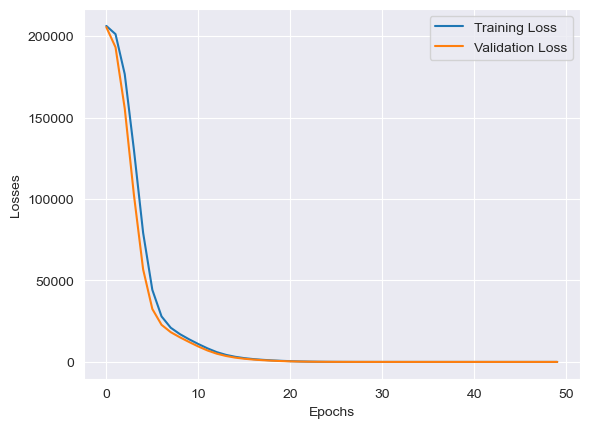

In [115]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.savefig("results/loss_curve.png", dpi=300, bbox_inches="tight")
plt.legend()

### Step_4 - Loading best model

In [116]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

### Step_5 - Evaluation

In [118]:
model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = criterion(train_preds, y_train_tensor)
    test_mse_loss = criterion(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 20.58510971069336
Testing MSE: 20.44481658935547


In [119]:
from sklearn.metrics import r2_score

print("r^2 score =", r2_score(y_test, test_preds))

r^2 score = 0.9322547545233861


In [120]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Predicted Values"])
pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Predicted Values
0,426.271545,429.38
1,481.419739,485.29
2,482.984863,480.40
3,449.920471,452.30
4,447.059631,446.47
...,...,...
1901,487.240936,490.50
1902,444.728516,443.31
1903,435.561066,441.14
1904,428.489929,438.47


# Training & Testing Conclusion of ANN_Regressor -
- The model shows stable convergence, with both training and validation loss decreasing smoothly.
- Minimal gap between train and validation loss indicates no significant overfitting.
- Achieved low MSE (~20) and a strong R² score of 0.93, indicating high predictive accuracy.
- Overall, the model performs well and captures the relationship between features and power output effectively.

*The model achieves strong performance with low error and high R² (0.93), showing good generalization without overfitting.*